<a href="https://colab.research.google.com/github/salvadorGoros/miner-a-de-datos/blob/main/CLUSTER_AGLOMERATIVO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Ejercicio 1 — Agrupación básica**

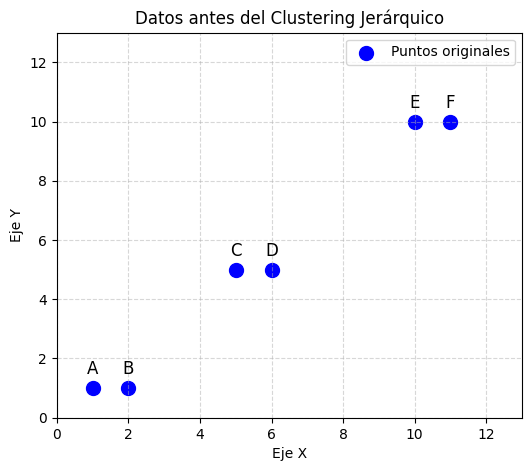

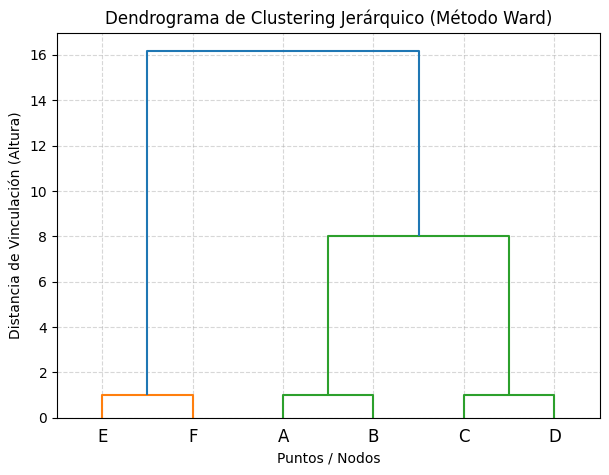

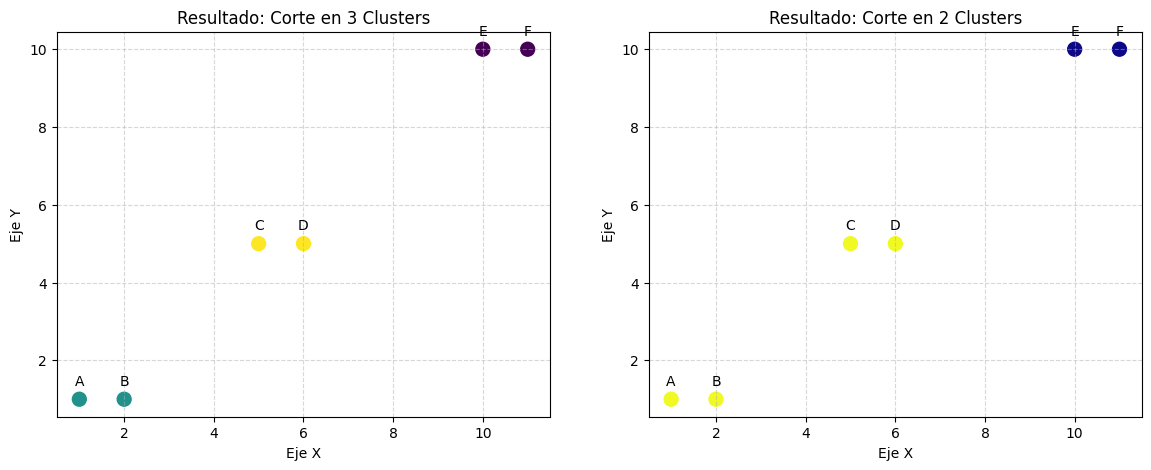

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

X = np.array([
    [1, 1],
    [2, 1],
    [5, 5],
    [6, 5],
    [10,10],
    [11,10]
])
labels = ['A', 'B', 'C', 'D', 'E', 'F']

fig1, ax1 = plt.subplots(figsize=(6, 5))
ax1.scatter(X[:, 0], X[:, 1], color='blue', s=100, label='Puntos originales')
for i, txt in enumerate(labels):
    ax1.annotate(txt, (X[i, 0], X[i, 1]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=12)
ax1.set_title('Datos antes del Clustering Jerárquico')
ax1.set_xlabel('Eje X')
ax1.set_ylabel('Eje Y')
ax1.set_xlim(0, 13)
ax1.set_ylim(0, 13)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()
plt.show()

Z = linkage(X, method='ward')

fig2, ax2 = plt.subplots(figsize=(7, 5))
dendrogram(Z, labels=labels, ax=ax2)
ax2.set_title('Dendrograma de Clustering Jerárquico (Método Ward)')
ax2.set_xlabel('Puntos / Nodos')
ax2.set_ylabel('Distancia de Vinculación (Altura)')
ax2.grid(True, linestyle='--', alpha=0.5)
plt.show()

cluster_3 = fcluster(Z, t=3, criterion='maxclust')
cluster_2 = fcluster(Z, t=2, criterion='maxclust')

fig3, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 5))

ax3.scatter(X[:, 0], X[:, 1], c=cluster_3, cmap='viridis', s=100)
for i, txt in enumerate(labels):
    ax3.annotate(f"{txt}", (X[i, 0], X[i, 1]), textcoords="offset points", xytext=(0,10), ha='center')
ax3.set_title('Resultado: Corte en 3 Clusters')
ax3.set_xlabel('Eje X')
ax3.set_ylabel('Eje Y')
ax3.grid(True, linestyle='--', alpha=0.5)

ax4.scatter(X[:, 0], X[:, 1], c=cluster_2, cmap='plasma', s=100)
for i, txt in enumerate(labels):
    ax4.annotate(f"{txt}", (X[i, 0], X[i, 1]), textcoords="offset points", xytext=(0,10), ha='center')
ax4.set_title('Resultado: Corte en 2 Clusters')
ax4.set_xlabel('Eje X')
ax4.set_ylabel('Eje Y')
ax4.grid(True, linestyle='--', alpha=0.5)

plt.show()

¿Qué puntos se unen primero y por qué?

Los pares A-B, C-D y E-F, están pegados, así que el algoritmo los une.

¿Qué sucede al cortar el dendrograma en una altura pequeña?

Se llena de grupos chiquitos y súper específicos.

¿Qué cambia al cortar el árbol más arriba?

Los grupos se empiezan a fusionar entre ellos. Pasan de ser grupitos compactos a tener plastas de datos más grandes y mezclados.

¿Qué significa la altura donde se unen dos ramas?

Mide qué tan diferentes son los grupos.
¿Cuántos clusters aparecen al cortar aproximadamente en distancia 8?

2 grupos: un megagrupo con todo lo de abajo A, B, C, D porque justo se alcanzan a fusionar a esa altura, y E, F

**Ejercicio 2 — Segmentación de clientes**

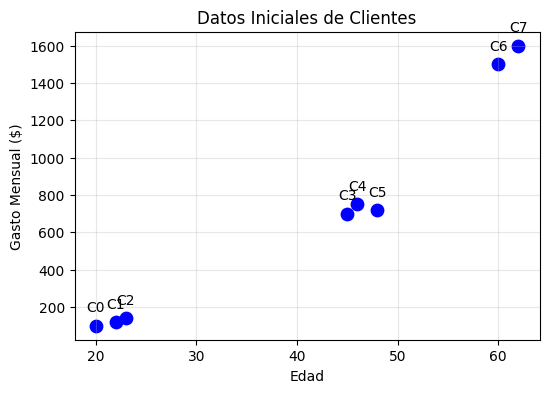

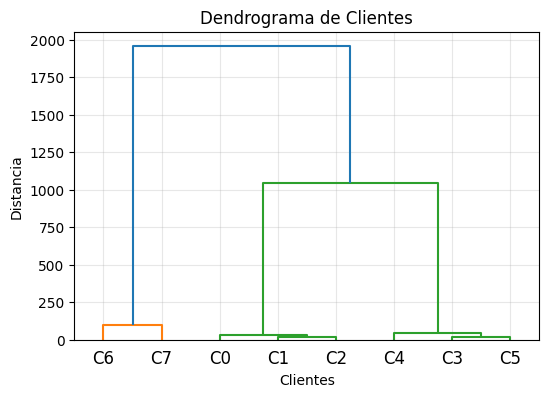

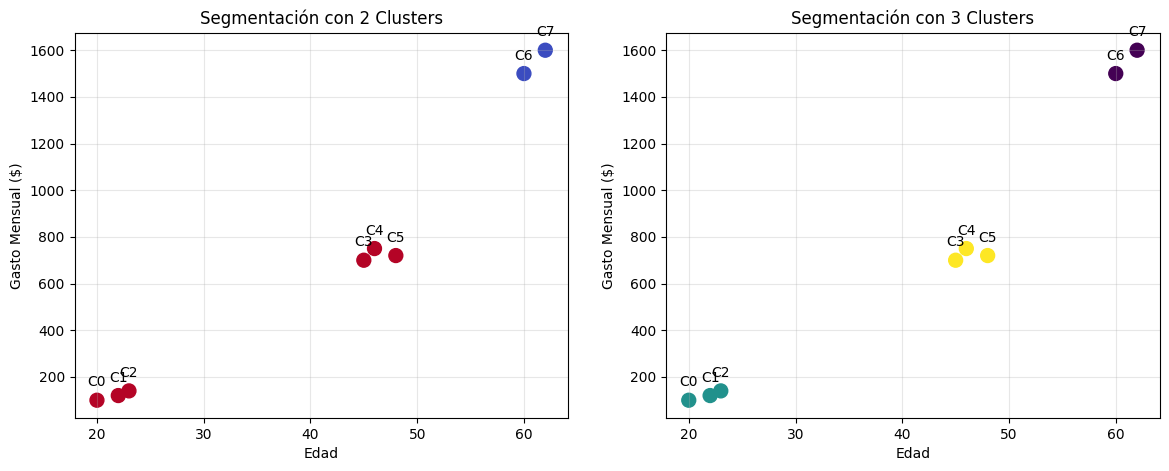

In [4]:
X = np.array([
    [20, 100],
    [22, 120],
    [23, 140],
    [45, 700],
    [46, 750],
    [48, 720],
    [60, 1500],
    [62, 1600]
])
labels = [f"C{i}" for i in range(len(X))]

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], color='blue', s=80)
for i, txt in enumerate(labels):
    plt.annotate(txt, (X[i, 0], X[i, 1]), textcoords="offset points", xytext=(0,10), ha='center')
plt.title('Datos Iniciales de Clientes')
plt.xlabel('Edad')
plt.ylabel('Gasto Mensual ($)')
plt.grid(True, alpha=0.3)
plt.show()

Z = linkage(X, method='ward')
plt.figure(figsize=(6, 4))
dendrogram(Z, labels=labels)
plt.title('Dendrograma de Clientes')
plt.xlabel('Clientes')
plt.ylabel('Distancia')
plt.grid(True, alpha=0.3)
plt.show()

c_2 = fcluster(Z, t=2, criterion='maxclust')
c_3 = fcluster(Z, t=3, criterion='maxclust')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(X[:, 0], X[:, 1], c=c_2, cmap='coolwarm', s=100)
for i, txt in enumerate(labels):
    ax1.annotate(txt, (X[i, 0], X[i, 1]), textcoords="offset points", xytext=(0,10), ha='center')
ax1.set_title('Segmentación con 2 Clusters')
ax1.set_xlabel('Edad')
ax1.set_ylabel('Gasto Mensual ($)')
ax1.grid(True, alpha=0.3)

ax2.scatter(X[:, 0], X[:, 1], c=c_3, cmap='viridis', s=100)
for i, txt in enumerate(labels):
    ax2.annotate(txt, (X[i, 0], X[i, 1]), textcoords="offset points", xytext=(0,10), ha='center')
ax2.set_title('Segmentación con 3 Clusters')
ax2.set_xlabel('Edad')
ax2.set_ylabel('Gasto Mensual ($)')
ax2.grid(True, alpha=0.3)

plt.show()

¿Qué clientes parecen más similares?

Los jóvenes entre ellos (C0, C1, C2), los adultos de gasto medio (C3, C4, C5), y los dos señores premium (C6, C7). Sus edades y gastos están muy pegaditos.

¿Qué grupos naturales identifica el algoritmo?

Identifica 3 grupos claros: los jóvenes universitarios/ahorradores, los adultos de gasto intermedio y los clientes VIP/senior de alto presupuesto.

¿Qué representa cada cluster desde el punto de vista comercial?

Grupo Bajo: Clientes jóvenes que gastan muy poco (potencial a futuro).

Grupo Medio: Clientes de mediana edad con consumo estable y moderado.

Grupo Alto: Clientes mayores con un altísimo poder adquisitivo.

¿Cuál sería una estrategia de marketing para cada grupo?

Para el Bajo: Descuentos estudiantiles, promociones en redes sociales y planes económicos para engancharlos.

Para el Medio: Programas de lealtad, suscripciones mensuales y productos familiares.

Para el Alto: Atención personalizada, productos premium/exclusivos y ofertas de lujo directas.

¿Por qué el algoritmo agrupa ciertos clientes?

Porque calcula la distancia en base al dinero que gastan y su edad. Al haber "saltos" tan grandes de dinero (de $140 a $700, y de $750 a $1500), el algoritmo detecta esos huecos vacíos y junta a los que se parecen en presupuesto.

**Ejercicio 3 — Rendimiento académico**

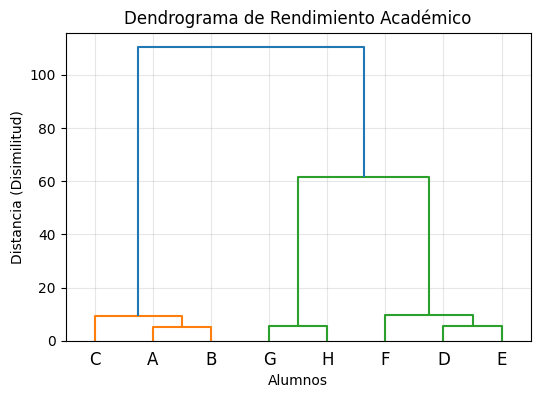

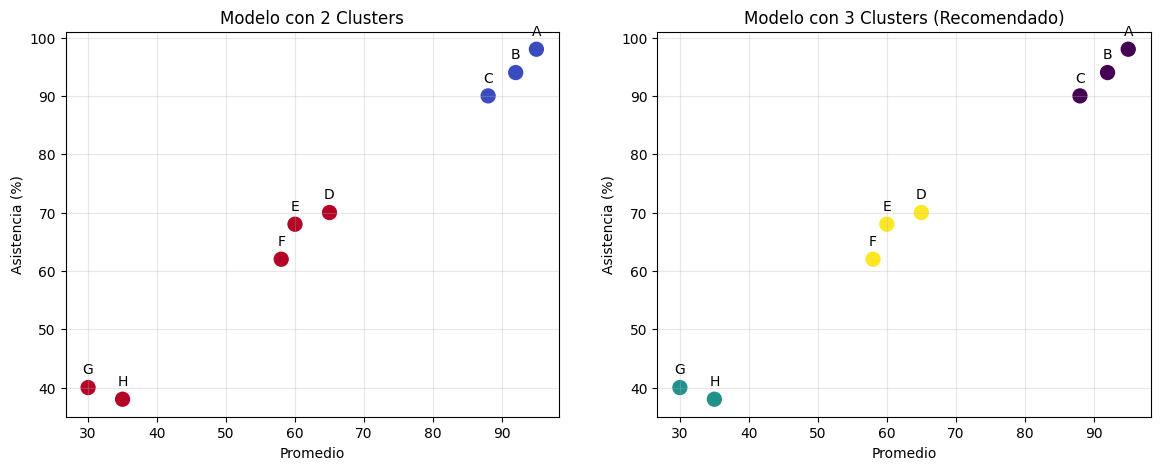

In [5]:
X = np.array([
    [95, 98],
    [92, 94],
    [88, 90],
    [65, 70],
    [60, 68],
    [58, 62],
    [30, 40],
    [35, 38]
])
labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']

Z = linkage(X, method='ward')

plt.figure(figsize=(6, 4))
dendrogram(Z, labels=labels)
plt.title('Dendrograma de Rendimiento Académico')
plt.xlabel('Alumnos')
plt.ylabel('Distancia (Disimilitud)')
plt.grid(True, alpha=0.3)
plt.show()

c_2 = fcluster(Z, t=2, criterion='maxclust')
c_3 = fcluster(Z, t=3, criterion='maxclust')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(X[:, 0], X[:, 1], c=c_2, cmap='coolwarm', s=100)
for i, txt in enumerate(labels):
    ax1.annotate(txt, (X[i, 0], X[i, 1]), textcoords="offset points", xytext=(0,10), ha='center')
ax1.set_title('Modelo con 2 Clusters')
ax1.set_xlabel('Promedio')
ax1.set_ylabel('Asistencia (%)')
ax1.grid(True, alpha=0.3)
ax2.scatter(X[:, 0], X[:, 1], c=c_3, cmap='viridis', s=100)
for i, txt in enumerate(labels):
    ax2.annotate(txt, (X[i, 0], X[i, 1]), textcoords="offset points", xytext=(0,10), ha='center')
ax2.set_title('Modelo con 3 Clusters (Recomendado)')
ax2.set_xlabel('Promedio')
ax2.set_ylabel('Asistencia (%)')
ax2.grid(True, alpha=0.3)

plt.show()

¿Qué alumnos se parecen más?

Los pares A-B, D-E y G-H. Están prácticamente pegados en sus calificaciones y porcentaje de asistencia.

¿Qué perfiles de estudiantes aparecen?

Destacados (A, B, C): Promedio alto y casi nunca faltan.

Regulares / En riesgo medio (D, E, F): Notas y asistencia aprobatorias pero bajas (panzando).

Críticos / Alerta roja (G, H): Reprobados y con altísimo ausentismo.

¿Qué decisión institucional podría tomarse con esta información?

Implementar tutorías obligatorias inmediatas y llamadas a padres para el grupo crítico, un programa de regularización/motivación para el grupo medio, y becas o incentivos para mantener motivados a los destacados.

¿Qué ocurre cuando el número de clusters cambia?

Con 2 clusters, el algoritmo solo divide a la escuela en "Aprobados" (A, B, C) y "Problema" (D, E, F, G, H), metiendo a los regulares y críticos en la misma bolsa.

Con 3 clusters, se logra separar con éxito a los alumnos que solo necesitan un empujón (D, E, F) de los que necesitan rescate urgente (G, H).

¿Qué grupo requeriría más intervención académica?

El grupo de los alumnos G y H (el grupo crítico). Tienen promedios de 30-35 y asistencias menores al 40%, lo que significa deserción o reprobación segura si no se actúa ya.